# Inizializzazione e Caricamento Dati
In questa sezione importiamo le librerie necessarie e carichiamo il dataset del MAGIC Gamma Telescope. Il dataset contiene 10 features continue e 1 label (h=hadron, g=gamma).

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from scipy.interpolate import interp1d

In [2]:
# Caricamento del dataset
col_names = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 
             'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']

df = pd.read_csv("magic04.data", names=col_names)

# Mappiamo le lettere in 0 (hadron) e 1 (gamma)
df['class'] = df['class'].map({'h': 0, 'g': 1})

print("Dataset caricato con successo in locale! Dimensioni:", df.shape)

Dataset caricato con successo in locale! Dimensioni: (19020, 11)


## Suddivisione del Dataset (Train, Val, Test)
Per addestrare i nostri modelli in modo corretto dividiamo il dataset in tre parti: il 60% per il Training Set, il 20% per il Validation Set e il 20% per il Test Set.

In [3]:
# Separiamo features e target
X = df.drop(['class'], axis=1)
y = df['class']
seed = 42

# Primo split: 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)

# Secondo split: 50% di Temp -> 20% Val, 20% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)

df_train = pd.concat([X_train, y_train], axis=1)

# Analisi Esplorativa
Controlliamo l'assenza di valori nulli o mancanti. Tracciamo poi istogrammi e boxplot per capire la distribuzione di ciascuna variabile e generiamo la matrice di correlazione per evidenziare relazioni lineari tra le features.

In [4]:
# Verifica dei valori NaN
print("Valori mancanti per colonna:\n", df.isnull().sum())
print(f"\nDuplicati trovati prima della pulizia: {df_train.duplicated().sum()}")

df_train = df_train.drop_duplicates()
print("Dataset Training dopo rimozione duplicati:", df_train.shape)

Valori mancanti per colonna:
 fLength     0
fWidth      0
fSize       0
fConc       0
fConc1      0
fAsym       0
fM3Long     0
fM3Trans    0
fAlpha      0
fDist       0
class       0
dtype: int64

Duplicati trovati prima della pulizia: 41
Dataset Training dopo rimozione duplicati: (11371, 11)


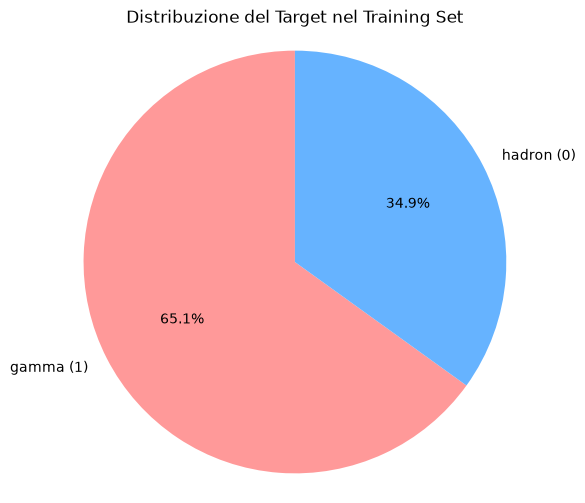

In [5]:
# Diagramma a torta della target
signal_class = df_train['class'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(signal_class, labels=['gamma (1)', 'hadron (0)'], autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('Distribuzione del Target nel Training Set')
plt.axis('equal')
plt.show()

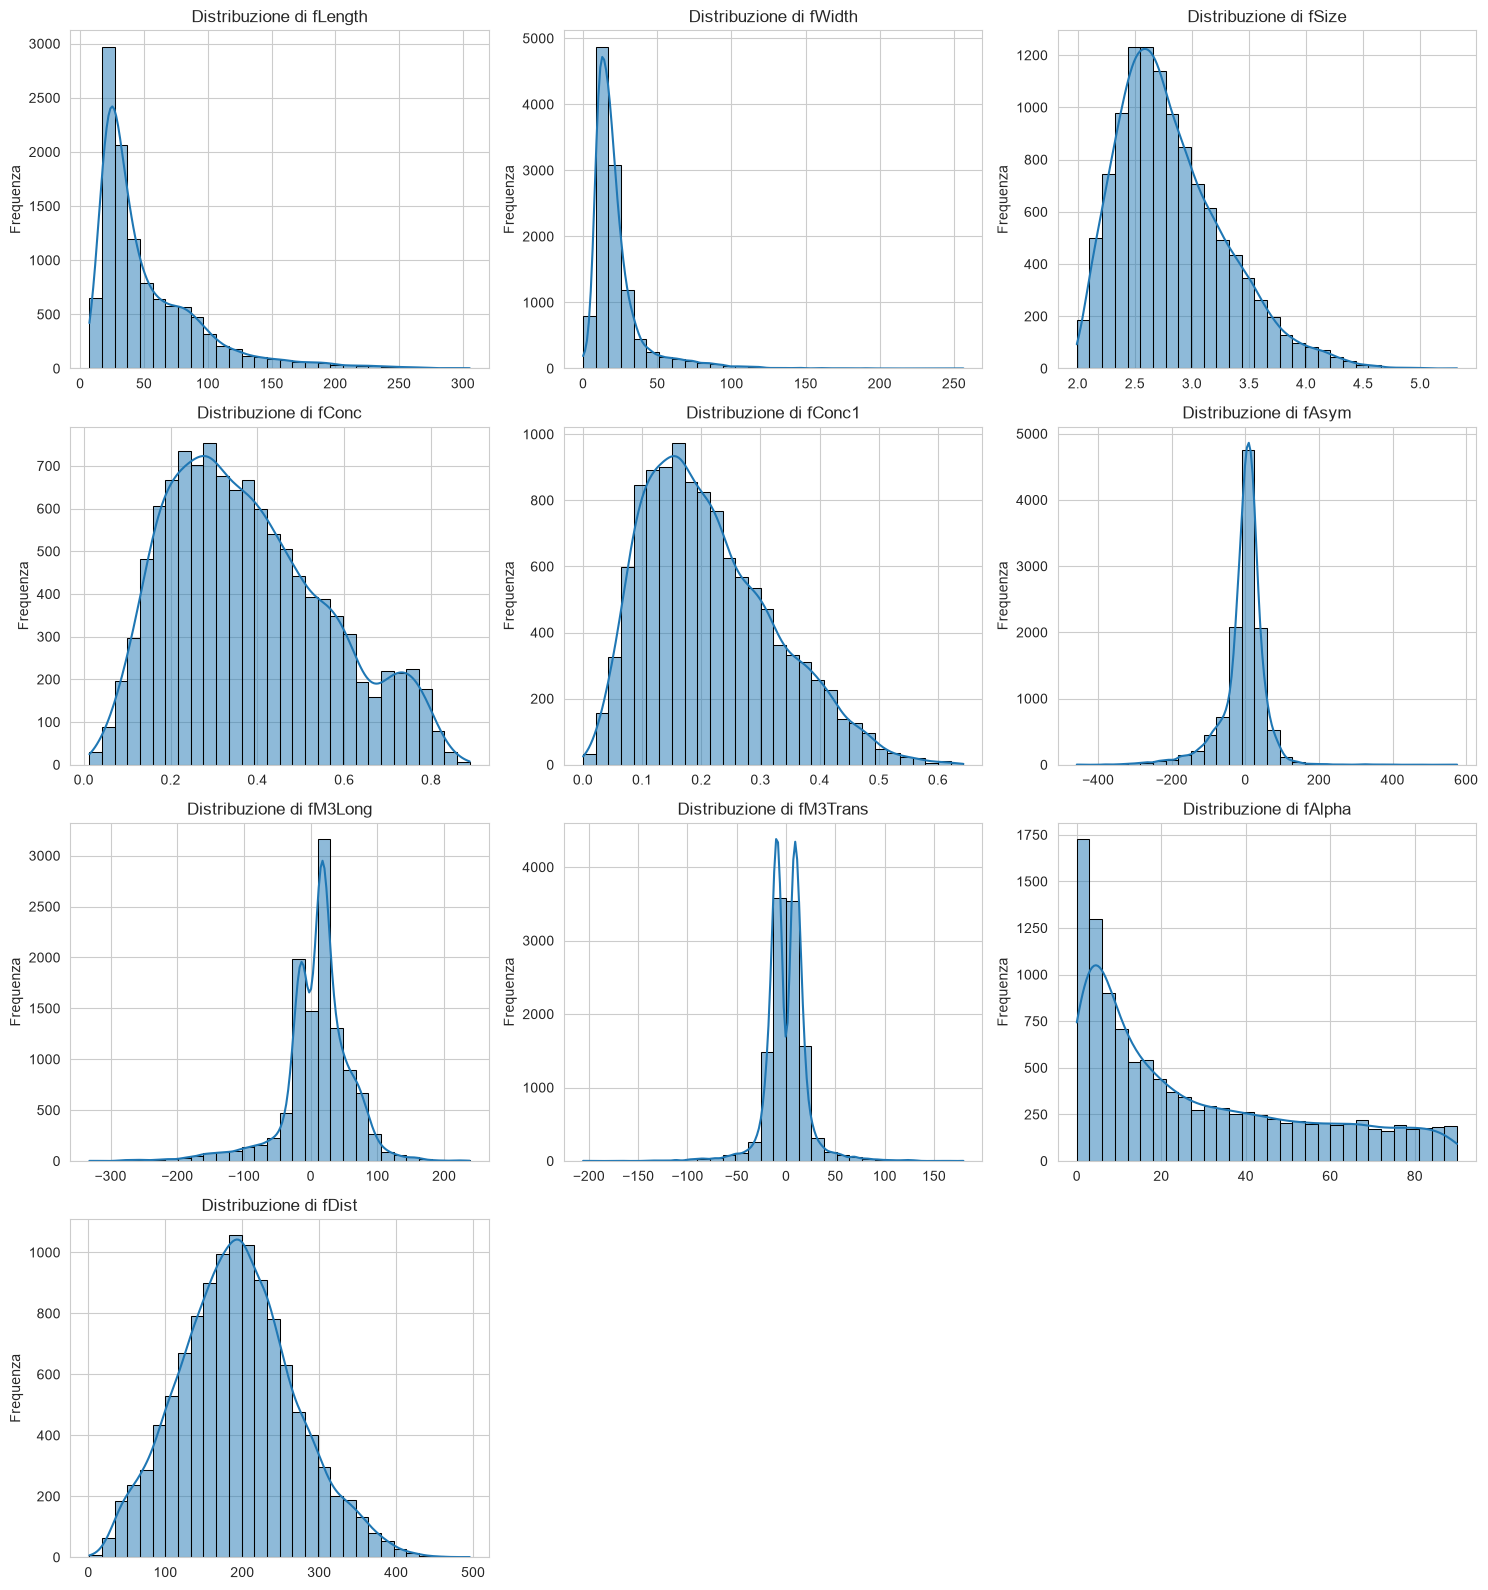

In [6]:
# Istogrammi
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [c for c in numeric_cols if c != 'class']
sns.set_style("whitegrid")
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_train[col], kde=True, bins=30, edgecolor='black')
    plt.title(f'Distribuzione di {col}')
    plt.xlabel('')
    plt.ylabel('Frequenza')

plt.tight_layout()
plt.show()

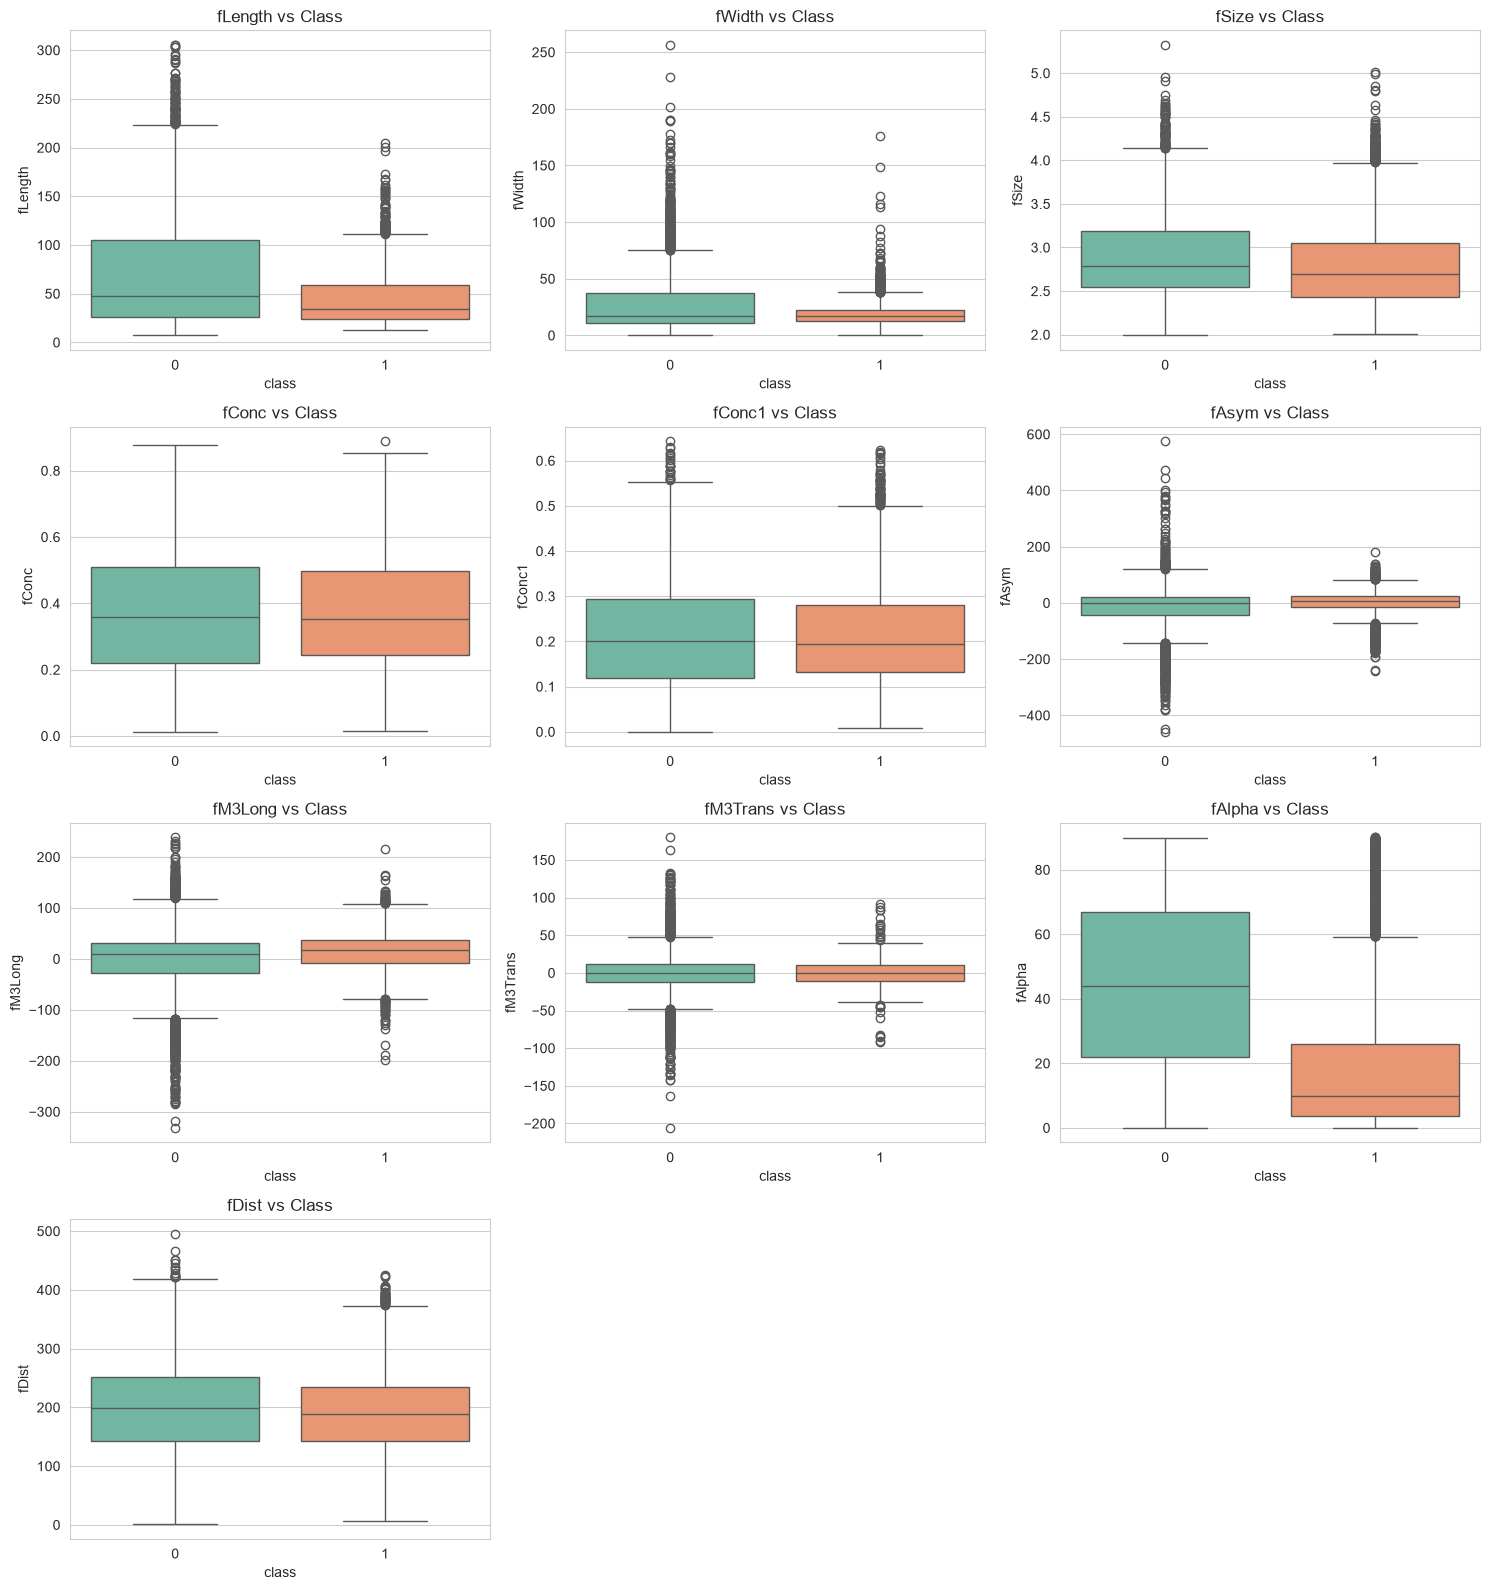

In [7]:
# Boxplot
plt.figure(figsize=(15, 4 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x='class', y=col, hue='class', data=df_train, palette='Set2', legend=False)
    plt.title(f'{col} vs Class')
plt.tight_layout()
plt.show()

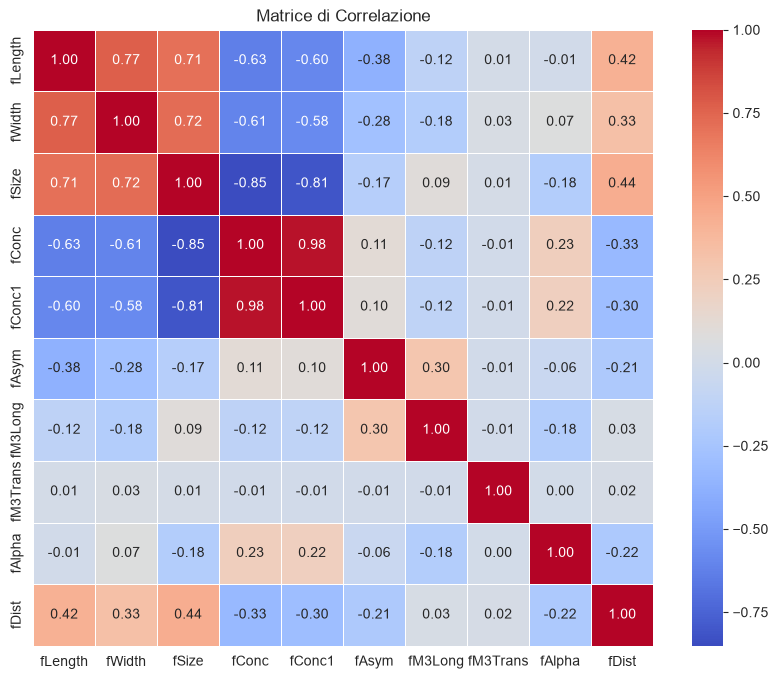

In [8]:
# Matrice di Correlazione
plt.figure(figsize=(10, 8))
corr_matrix = df_train[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matrice di Correlazione')
plt.show()

# Preprocessing e Scalatura
Standardizziamo i dati in modo che abbiano media 0 e deviazione standard 1, il che aiuta notevolmente le reti neurali a convergere. Assicuriamo anche che i target siano di tipo intero.

In [9]:
scaler = StandardScaler()

# Addestriamo lo scaler SOLO sul Train per evitare data leak
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train = y_train.astype("int64")
y_test = y_test.astype("int64")
y_val = y_val.astype("int64")

# Introduzione del Rumore (Noise Injection)
Per studiare la robustezza dei modelli, creeremo due tipi di rumore:
- **Feature Noise:** Aggiunta di rumore gaussiano alle features.
- **Label Noise:** Inversione casuale di una percentuale delle etichette (es. da 0 a 1 e viceversa).

In [10]:
def add_gaussian_noise(X, noise_level=0.1, seed=42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise

def add_label_noise(y, noise_level=0.1, seed=42):
    np.random.seed(seed)
    y_noisy = np.array(y).copy()
    n_samples = len(y_noisy)
    n_flips = int(n_samples * noise_level)
    flip_indices = np.random.choice(n_samples, size=n_flips, replace=False)
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]
    return y_noisy

noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

# Modelli Neurali
Implementiamo due varianti di rete neurale:
1. **Base:** Architettura semplice con due strati nascosti.
2. **Pro (Regolarizzata):** Architettura più profonda che include Dropout, Regolarizzazione L2, Class Weight e Early Stopping per limitare l'overfitting quando i dati sono rumorosi.

In [11]:
def train_base_network(X_train_input, y_train_input, X_val_input, y_val_input, epochs=75, batch_size=32, verbose=0):
    model = Sequential()
    model.add(Input(shape=(X_train_input.shape[1],)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    history = model.fit(X_train_input, y_train_input, epochs=epochs, batch_size=batch_size, 
                        validation_data=(X_val_input, y_val_input), verbose=verbose)

    val_acc = history.history['val_accuracy'][-1]
    return model, history

def train_pro_network(X_train_input, y_train_input, X_val_input, y_val_input, epochs=150, batch_size=32, verbose=0, dropout_rate=0.2, l2_lambda=1e-4, patience=15):
    model = Sequential()
    model.add(Input(shape=(X_train_input.shape[1],)))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    classes = np.unique(y_train_input)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=np.array(y_train_input))
    class_weights_dict = {int(c): w for c, w in zip(classes, weights)}

    early_stop = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

    history = model.fit(X_train_input, y_train_input, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val_input, y_val_input), class_weight=class_weights_dict,
                        callbacks=[early_stop], verbose=verbose)

    return model, history

def evaluate_network(model, history, X_test_input, y_test_input, model_name="Modello"):
    print(f"\n" + "="*50)
    print(f" RISULTATI ESPERIMENTO: {model_name}")
    print("="*50)
    score = model.evaluate(X_test_input, y_test_input, verbose=0)
    print(f"Test loss: {score[0]:.4f} - Test accuracy: {score[1]:.4f}")

    # Grafici di Accuracy e Loss
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_ylabel('Accuracy'); axes[0].set_xlabel('Epoch')
    axes[0].legend(loc='lower right'); axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_ylabel('Loss'); axes[1].set_xlabel('Epoch')
    axes[1].legend(loc='upper right'); axes[1].grid(True)
    plt.tight_layout()
    plt.show()

    y_pred_probs = model.predict(X_test_input, verbose=0)
    y_pred_nn = (y_pred_probs > 0.5).astype("int64")
    
    # Matrice di Confusione
    cm = confusion_matrix(y_test_input, y_pred_nn)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Report finale
    print(f"Accuratezza Finale: {accuracy_score(y_test_input, y_pred_nn):.4f}")
    print("\nReport di Classificazione:")
    print(classification_report(y_test_input, y_pred_nn, zero_division=0))
    print("="*50 + "\n")

## Addestramento Rete Neurale Base

>>> Addestramento NN Base Baseline (Dati Puliti)

 RISULTATI ESPERIMENTO: NN Baseline
Test loss: 0.3211 - Test accuracy: 0.8749


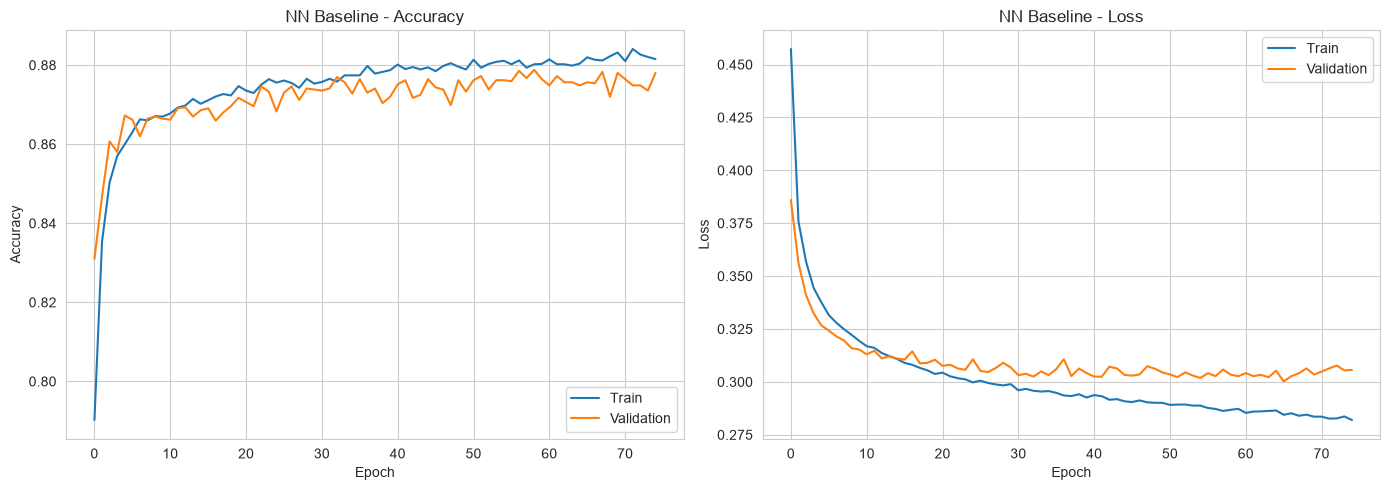

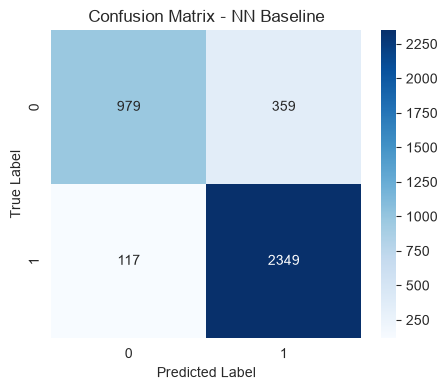

Accuratezza Finale: 0.8749

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1338
           1       0.87      0.95      0.91      2466

    accuracy                           0.87      3804
   macro avg       0.88      0.84      0.86      3804
weighted avg       0.88      0.87      0.87      3804



--- Addestramento NN Base con RUMORE 10% ---

 RISULTATI ESPERIMENTO: NN Base Feature Noise 10%
Test loss: 0.3308 - Test accuracy: 0.8651


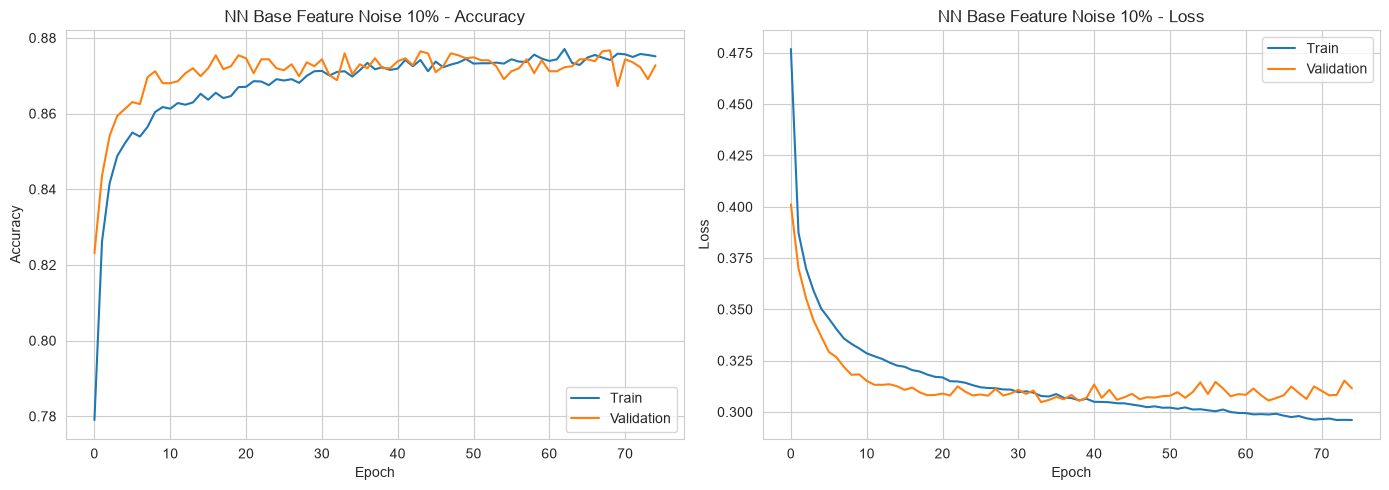

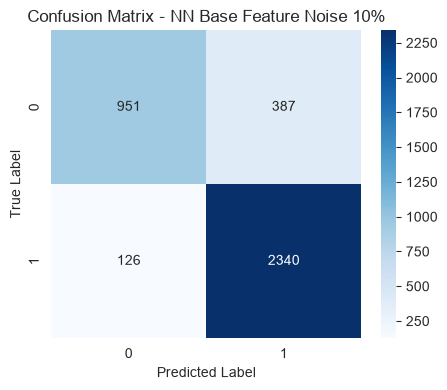

Accuratezza Finale: 0.8651

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      1338
           1       0.86      0.95      0.90      2466

    accuracy                           0.87      3804
   macro avg       0.87      0.83      0.84      3804
weighted avg       0.87      0.87      0.86      3804



 RISULTATI ESPERIMENTO: NN Base Label Noise 10%
Test loss: 0.3543 - Test accuracy: 0.8665


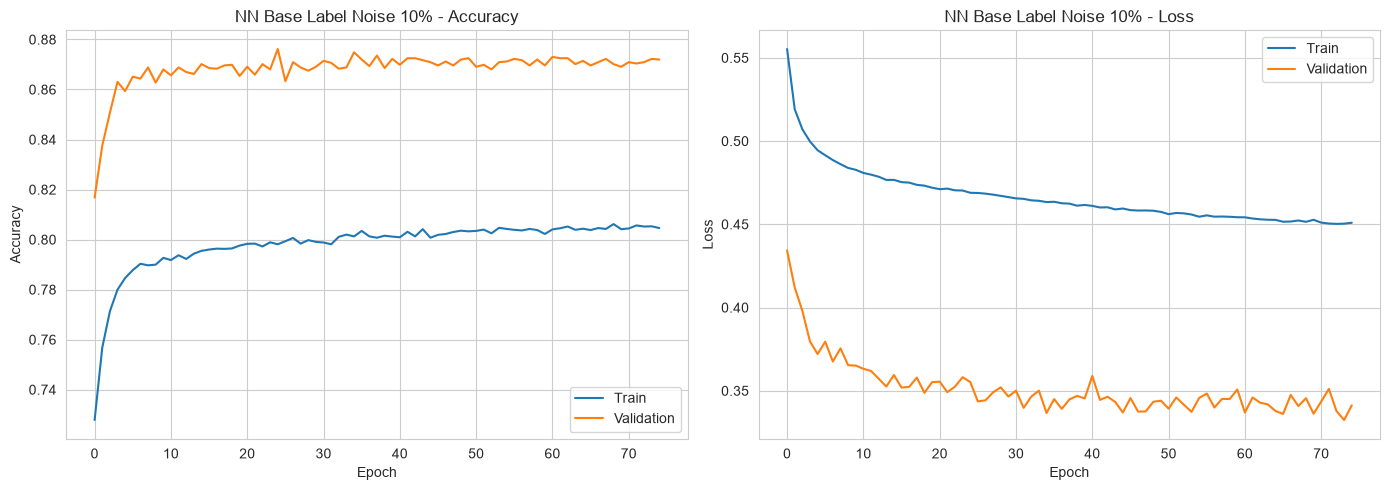

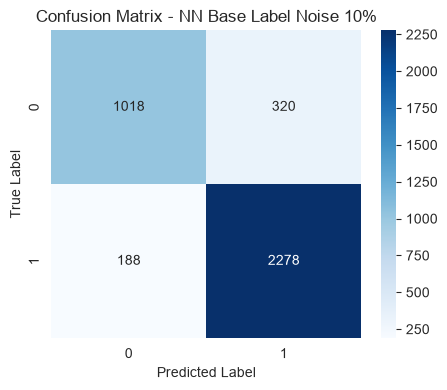

Accuratezza Finale: 0.8665

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1338
           1       0.88      0.92      0.90      2466

    accuracy                           0.87      3804
   macro avg       0.86      0.84      0.85      3804
weighted avg       0.87      0.87      0.86      3804



 RISULTATI ESPERIMENTO: NN Base Combinato 10%
Test loss: 0.3669 - Test accuracy: 0.8638


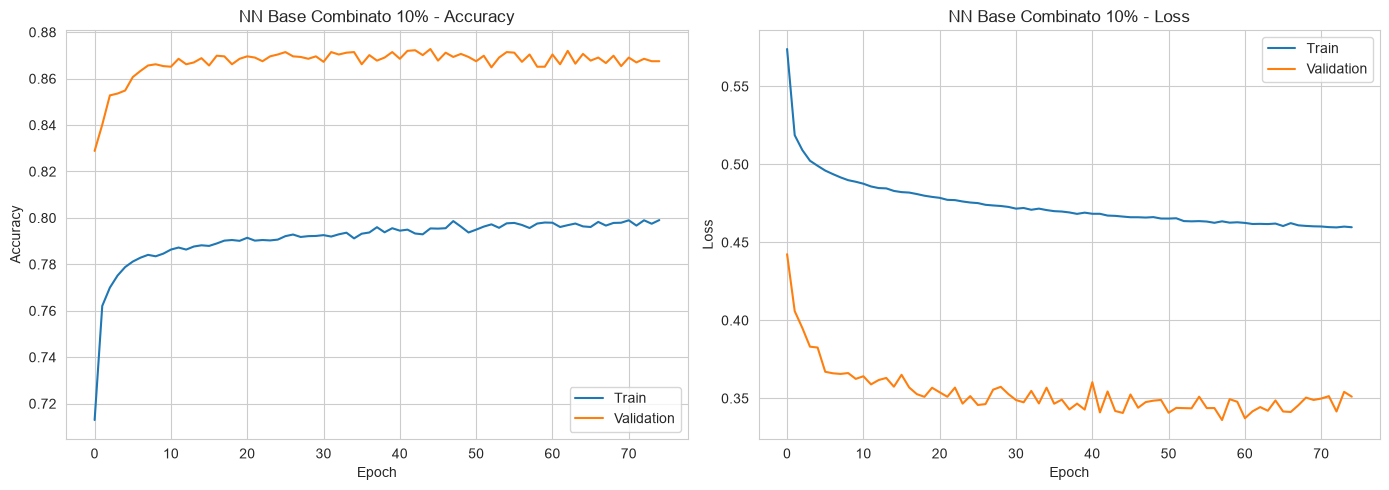

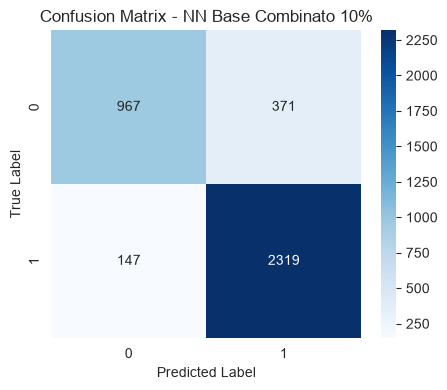

Accuratezza Finale: 0.8638

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.87      0.72      0.79      1338
           1       0.86      0.94      0.90      2466

    accuracy                           0.86      3804
   macro avg       0.87      0.83      0.84      3804
weighted avg       0.86      0.86      0.86      3804



--- Addestramento NN Base con RUMORE 20% ---

 RISULTATI ESPERIMENTO: NN Base Feature Noise 20%
Test loss: 0.3431 - Test accuracy: 0.8612


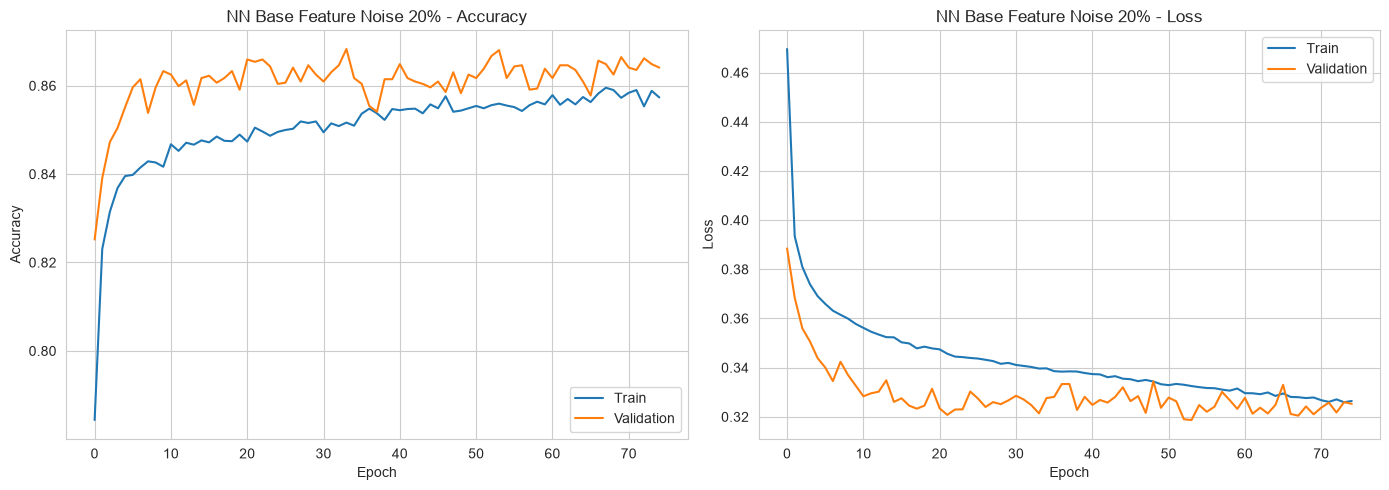

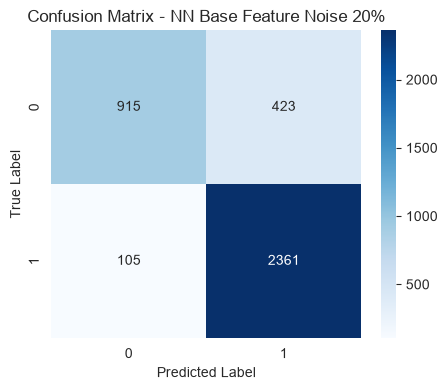

Accuratezza Finale: 0.8612

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1338
           1       0.85      0.96      0.90      2466

    accuracy                           0.86      3804
   macro avg       0.87      0.82      0.84      3804
weighted avg       0.87      0.86      0.86      3804



 RISULTATI ESPERIMENTO: NN Base Label Noise 20%
Test loss: 0.4407 - Test accuracy: 0.8509


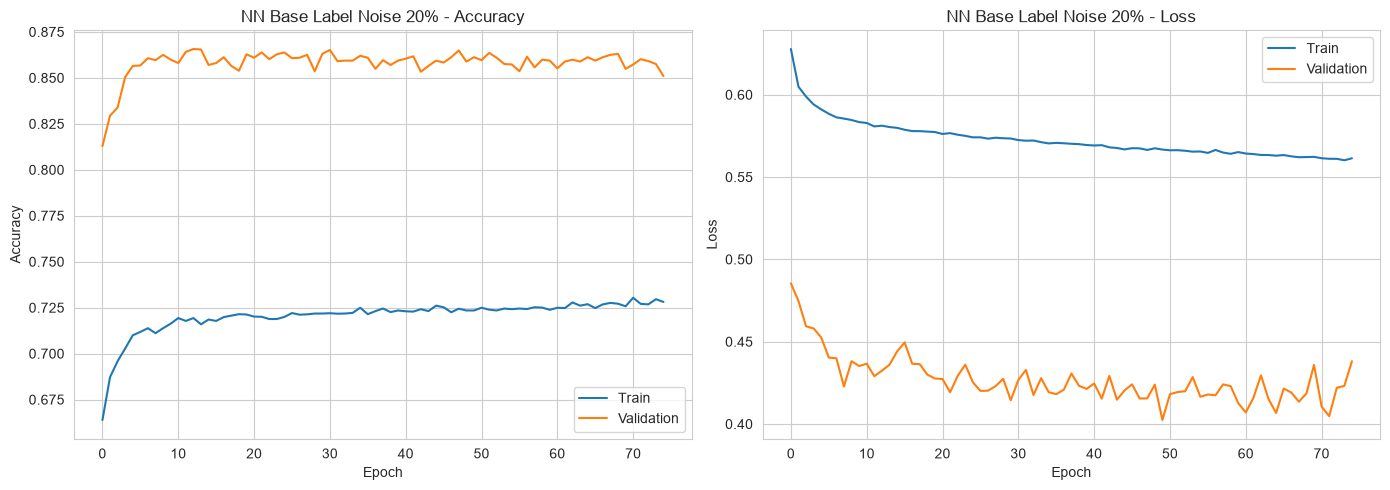

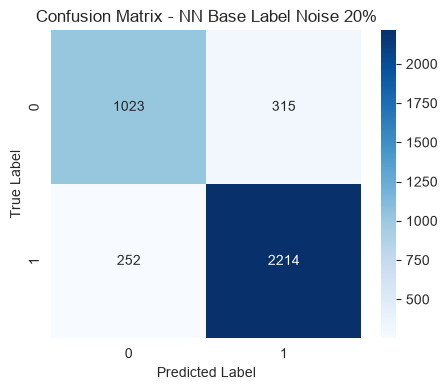

Accuratezza Finale: 0.8509

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      1338
           1       0.88      0.90      0.89      2466

    accuracy                           0.85      3804
   macro avg       0.84      0.83      0.83      3804
weighted avg       0.85      0.85      0.85      3804



 RISULTATI ESPERIMENTO: NN Base Combinato 20%
Test loss: 0.4332 - Test accuracy: 0.8491


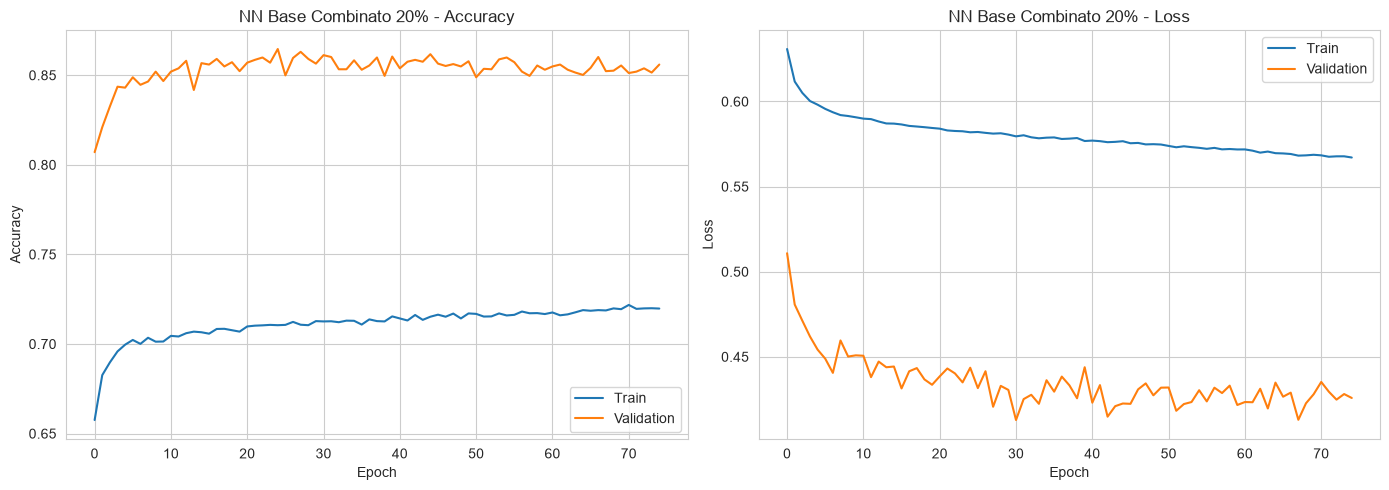

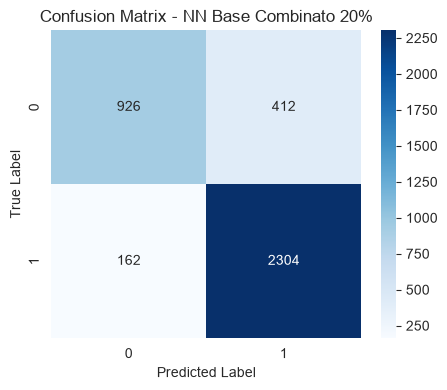

Accuratezza Finale: 0.8491

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      1338
           1       0.85      0.93      0.89      2466

    accuracy                           0.85      3804
   macro avg       0.85      0.81      0.83      3804
weighted avg       0.85      0.85      0.84      3804



--- Addestramento NN Base con RUMORE 30% ---

 RISULTATI ESPERIMENTO: NN Base Feature Noise 30%
Test loss: 0.3790 - Test accuracy: 0.8365


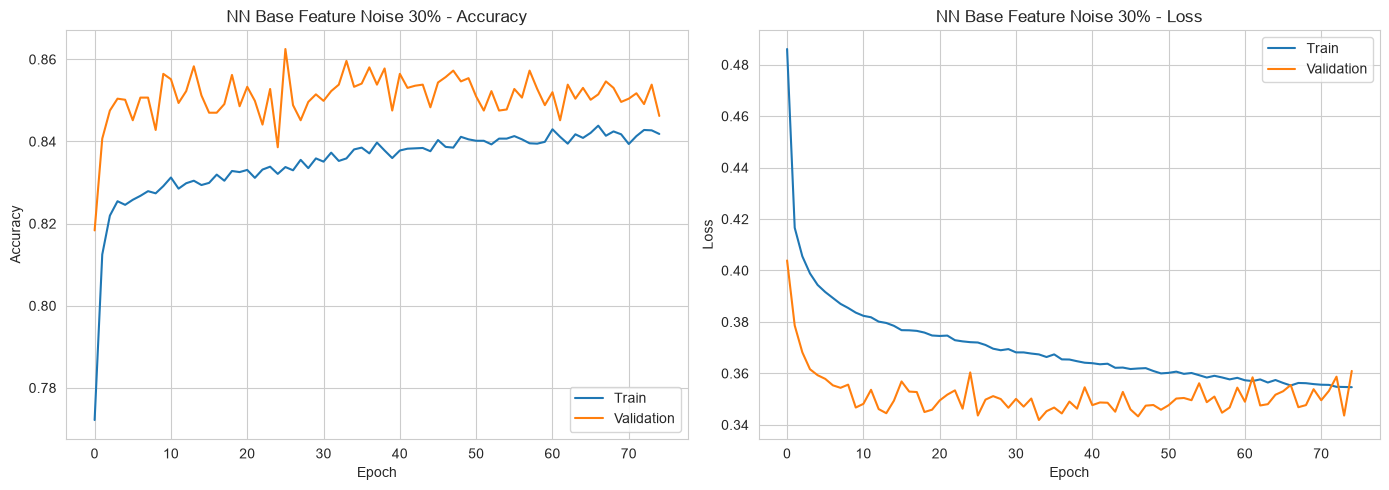

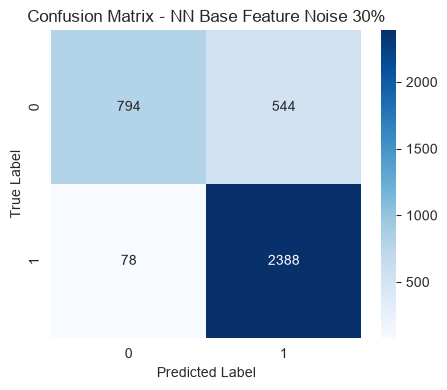

Accuratezza Finale: 0.8365

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.91      0.59      0.72      1338
           1       0.81      0.97      0.88      2466

    accuracy                           0.84      3804
   macro avg       0.86      0.78      0.80      3804
weighted avg       0.85      0.84      0.83      3804



 RISULTATI ESPERIMENTO: NN Base Label Noise 30%
Test loss: 0.5175 - Test accuracy: 0.8076


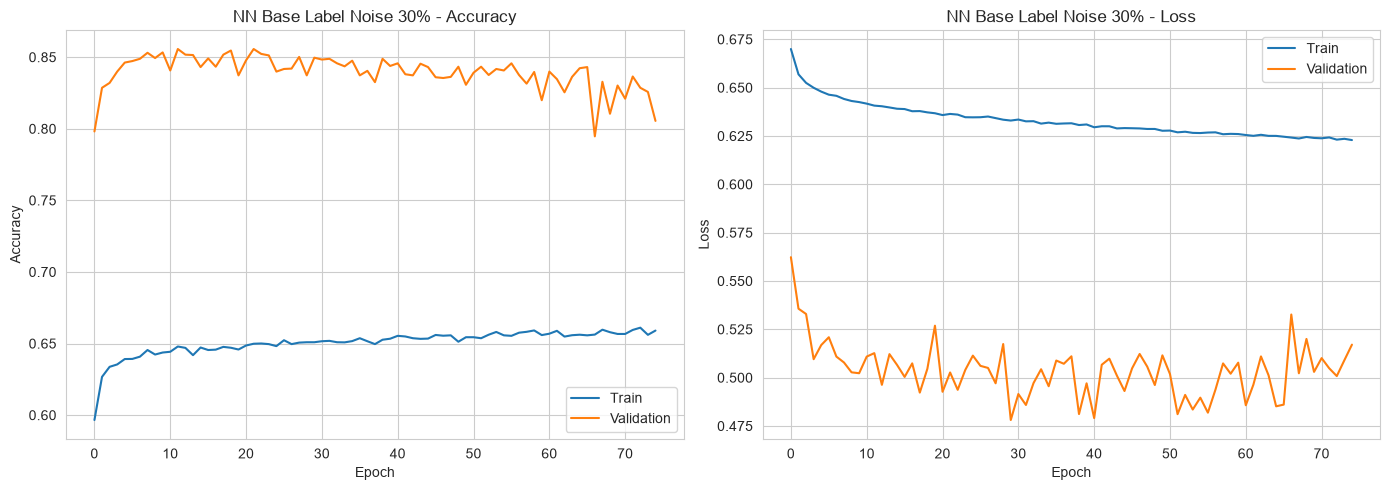

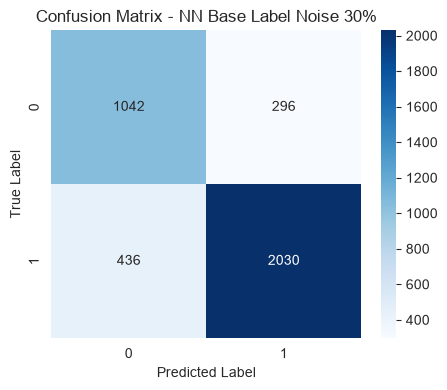

Accuratezza Finale: 0.8076

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      1338
           1       0.87      0.82      0.85      2466

    accuracy                           0.81      3804
   macro avg       0.79      0.80      0.79      3804
weighted avg       0.81      0.81      0.81      3804



 RISULTATI ESPERIMENTO: NN Base Combinato 30%
Test loss: 0.5044 - Test accuracy: 0.8157


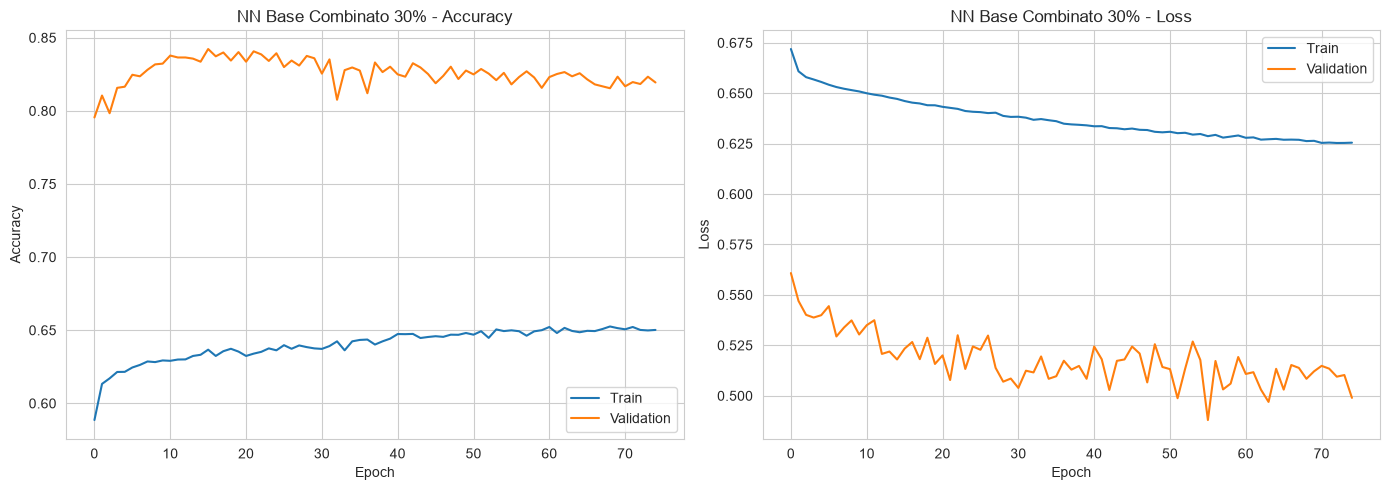

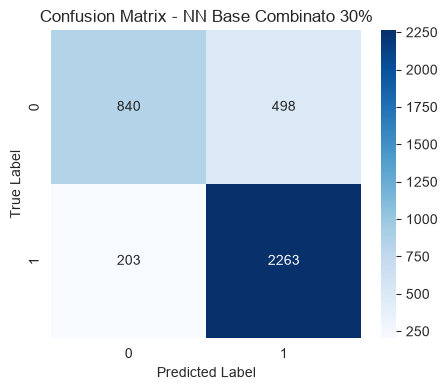

Accuratezza Finale: 0.8157

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.81      0.63      0.71      1338
           1       0.82      0.92      0.87      2466

    accuracy                           0.82      3804
   macro avg       0.81      0.77      0.79      3804
weighted avg       0.81      0.82      0.81      3804



--- Addestramento NN Base con RUMORE 40% ---

 RISULTATI ESPERIMENTO: NN Base Feature Noise 40%
Test loss: 0.3865 - Test accuracy: 0.8260


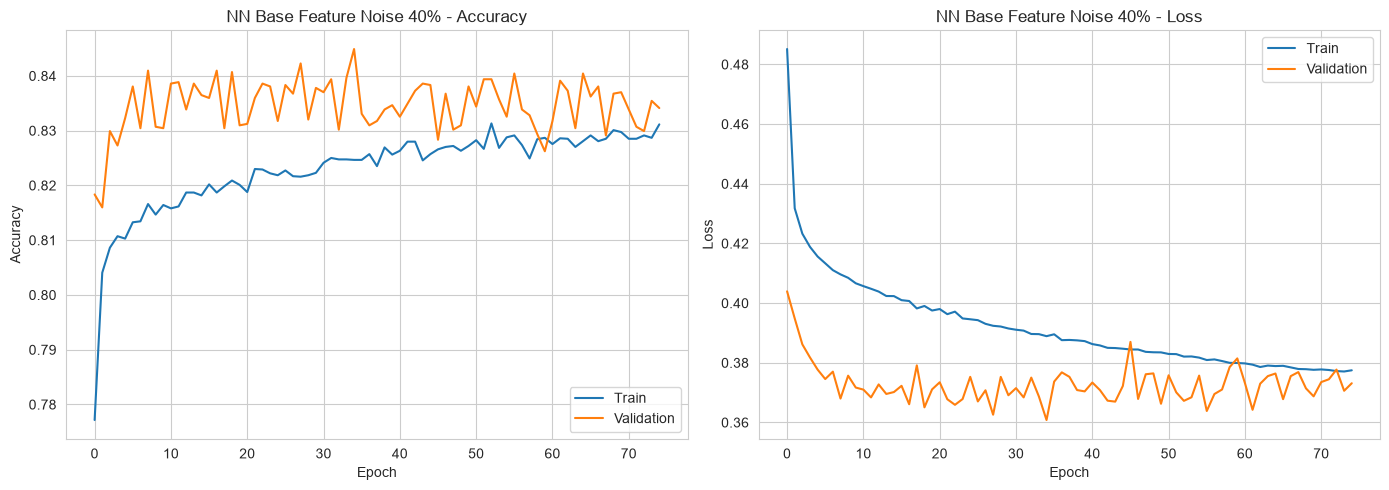

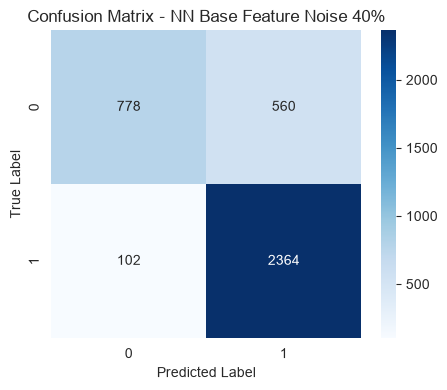

Accuratezza Finale: 0.8260

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.88      0.58      0.70      1338
           1       0.81      0.96      0.88      2466

    accuracy                           0.83      3804
   macro avg       0.85      0.77      0.79      3804
weighted avg       0.84      0.83      0.82      3804



 RISULTATI ESPERIMENTO: NN Base Label Noise 40%
Test loss: 0.5949 - Test accuracy: 0.7508


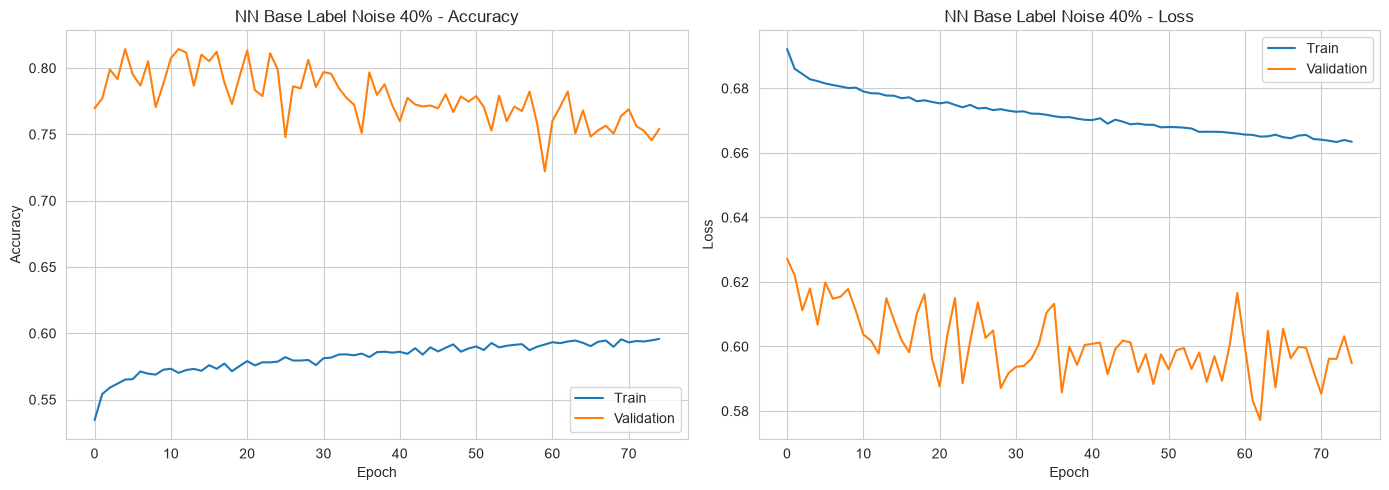

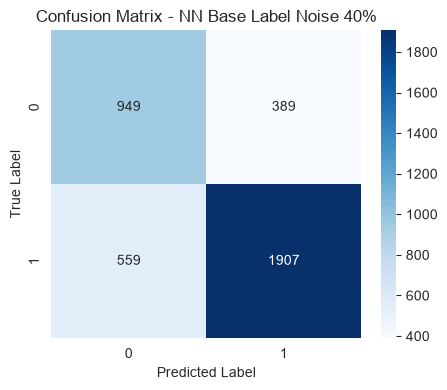

Accuratezza Finale: 0.7508

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.63      0.71      0.67      1338
           1       0.83      0.77      0.80      2466

    accuracy                           0.75      3804
   macro avg       0.73      0.74      0.73      3804
weighted avg       0.76      0.75      0.75      3804




KeyboardInterrupt: 

In [12]:
# --- BASELINE (Dati Puliti) ---
print(">>> Addestramento NN Base Baseline (Dati Puliti)")
model_nn_clean, hist_nn_clean = train_base_network(X_train_scaled, y_train, X_val_scaled, y_val)
evaluate_network(model_nn_clean, hist_nn_clean, X_test_scaled, y_test, model_name="NN Baseline")

modelli_nn_fn = {'Baseline': model_nn_clean}
modelli_nn_ln = {'Baseline': model_nn_clean}
modelli_nn_comb = {'Baseline': model_nn_clean}

# Addestramento ai vari livelli di rumore
for lvl in noise_levels:
    print(f"\n--- Addestramento NN Base con RUMORE {int(lvl*100)}% ---")

    X_fn = add_gaussian_noise(X_train_scaled, noise_level=lvl)
    model_fn, hist_fn = train_base_network(X_fn, y_train, X_val_scaled, y_val)
    modelli_nn_fn[f'Rumore {int(lvl*100)}%'] = model_fn
    evaluate_network(model_fn, hist_fn, X_test_scaled, y_test, model_name=f"NN Base Feature Noise {int(lvl*100)}%")

    y_ln = add_label_noise(y_train, noise_level=lvl) 
    model_ln, hist_ln = train_base_network(X_train_scaled, y_ln, X_val_scaled, y_val)
    modelli_nn_ln[f'Rumore {int(lvl*100)}%'] = model_ln
    evaluate_network(model_ln, hist_ln, X_test_scaled, y_test, model_name=f"NN Base Label Noise {int(lvl*100)}%")

    model_comb, hist_comb = train_base_network(X_fn, y_ln, X_val_scaled, y_val)
    modelli_nn_comb[f'Rumore {int(lvl*100)}%'] = model_comb
    evaluate_network(model_comb, hist_comb, X_test_scaled, y_test, model_name=f"NN Base Combinato {int(lvl*100)}%")

## Addestramento Rete Neurale PRO (Regolarizzata)

In [ ]:
# --- BASELINE PRO (Dati Puliti) ---
print(">>> Addestramento NN Pro Baseline (Dati Puliti)")
model_nn_clean_pro, hist_nn_clean_pro = train_pro_network(X_train_scaled, y_train, X_val_scaled, y_val)
evaluate_network(model_nn_clean_pro, hist_nn_clean_pro, X_test_scaled, y_test, model_name="NN Baseline PRO")

# Uso la baseline corretta per la rete PRO!
modelli_nn_fn_pro = {'Baseline': model_nn_clean_pro}
modelli_nn_ln_pro = {'Baseline': model_nn_clean_pro}
modelli_nn_comb_pro = {'Baseline': model_nn_clean_pro}

# Addestramento ai vari livelli di rumore per la versione PRO
for lvl in noise_levels:
    print(f"\n--- Addestramento NN PRO con RUMORE {int(lvl*100)}% ---")

    X_fn = add_gaussian_noise(X_train_scaled, noise_level=lvl)
    model_fn_pro, hist_fn_pro = train_pro_network(X_fn, y_train, X_val_scaled, y_val)
    modelli_nn_fn_pro[f'Rumore {int(lvl*100)}%'] = model_fn_pro
    evaluate_network(model_fn_pro, hist_fn_pro, X_test_scaled, y_test, model_name=f"NN Pro Feature Noise {int(lvl*100)}%")

    y_ln = add_label_noise(y_train, noise_level=lvl) 
    model_ln_pro, hist_ln_pro = train_pro_network(X_train_scaled, y_ln, X_val_scaled, y_val)
    modelli_nn_ln_pro[f'Rumore {int(lvl*100)}%'] = model_ln_pro
    evaluate_network(model_ln_pro, hist_ln_pro, X_test_scaled, y_test, model_name=f"NN Pro Label Noise {int(lvl*100)}%")

    model_comb_pro, hist_comb_pro = train_pro_network(X_fn, y_ln, X_val_scaled, y_val)
    modelli_nn_comb_pro[f'Rumore {int(lvl*100)}%'] = model_comb_pro
    evaluate_network(model_comb_pro, hist_comb_pro, X_test_scaled, y_test, model_name=f"NN Pro Combinato {int(lvl*100)}%")

# Valutazione e Confronto
Valutiamo i modelli usando Accuracy, F1 Macro, Recall Macro e AUC per capire come ciascuna tipologia di rumore ne degrada le performance. Infine stampiamo grafici che comparano direttamente la robustezza della rete base contro la rete PRO regolarizzata.

In [ ]:
PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e']

def _nn_proba(model, X):
    return np.asarray(model.predict(X, verbose=0)).ravel()

def compute_metrics(model, X_test_input, y_test_input):
    proba = _nn_proba(model, X_test_input)
    y_pred = (proba > 0.5).astype(int)
    return {
        'accuracy':     accuracy_score(y_test_input, y_pred),
        'recall_macro': recall_score(y_test_input, y_pred, average='macro', zero_division=0),
        'f1_macro':     f1_score(y_test_input, y_pred, average='macro', zero_division=0),
        'auc':          roc_auc_score(y_test_input, proba),
    }

def _level_from_name(name):
    if 'baseline' in name.lower(): return 0
    m = re.search(r'(\d+)', name)
    return int(m.group(1)) if m else np.nan

def results_dataframe(models_dict, X_test_input, y_test_input, modello='NN base', tipo_rumore=''):
    rows = []
    for name, model in models_dict.items():
        rows.append({'modello': modello, 'tipo_rumore': tipo_rumore,
                     'livello': _level_from_name(name),
                     **compute_metrics(model, X_test_input, y_test_input)})
    return pd.DataFrame(rows).sort_values('livello').reset_index(drop=True)

# Dataframe Modelli Base
df_fn   = results_dataframe(modelli_nn_fn,   X_test_scaled, y_test, 'NN base', 'Feature noise')
df_ln   = results_dataframe(modelli_nn_ln,   X_test_scaled, y_test, 'NN base', 'Label noise')
df_comb = results_dataframe(modelli_nn_comb, X_test_scaled, y_test, 'NN base', 'Combinato')

# Dataframe Modelli PRO
df_fn_pro = results_dataframe(modelli_nn_fn_pro, X_test_scaled, y_test, 'NN pro', 'Feature noise')
df_ln_pro = results_dataframe(modelli_nn_ln_pro, X_test_scaled, y_test, 'NN pro', 'Label noise')
df_comb_pro = results_dataframe(modelli_nn_comb_pro, X_test_scaled, y_test, 'NN pro', 'Combinato')

In [ ]:
def plot_metrics_grid(dfs, title='Impatto del rumore sulle metriche (NN base)'):
    metriche = [('accuracy','Accuracy'), ('f1_macro','F1 (macro)'),
                ('recall_macro','Recall (macro)'), ('auc','AUC')]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (key, nice) in zip(axes.ravel(), metriche):
        for (label, df), color in zip(dfs.items(), PALETTE):
            d = df.sort_values('livello')
            ax.plot(d['livello'], d[key], marker='o', lw=2, markersize=6, color=color, label=label)
        ax.set_title(nice, fontweight='bold'); ax.set_xlabel('Livello di rumore (%)')
        ax.set_ylabel(nice); ax.grid(alpha=0.3)
    axes.ravel()[0].legend(frameon=True)
    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

def plot_degradation(dfs, metric='accuracy', title=None):
    plt.figure(figsize=(9, 5.5))
    for (label, df), color in zip(dfs.items(), PALETTE):
        d = df.sort_values('livello')
        plt.plot(d['livello'], d[metric], marker='o', lw=2.2, markersize=7, color=color, label=label)
        plt.annotate(f"{d[metric].iloc[-1]:.2f}", (d['livello'].iloc[-1], d[metric].iloc[-1]),
                     textcoords="offset points", xytext=(6, 0), fontsize=9, color=color)
    first = list(dfs.values())[0]
    b = first[first['livello'] == 0][metric]
    if len(b):
        plt.axhline(float(b.iloc[0]), ls='--', color='grey', alpha=0.6, lw=1, label='Baseline (0%)')
    plt.xlabel('Livello di rumore (%)'); plt.ylabel(metric.replace('_', ' ').upper())
    plt.title(title or f'Degrado di {metric} al crescere del rumore', fontweight='bold')
    plt.grid(alpha=0.3); plt.legend(frameon=True); plt.tight_layout(); plt.show()

def plot_base_vs_pro(df_base, df_pro, metric='accuracy', tipo='Feature noise'):
    m = df_base.merge(df_pro, on='livello', suffixes=('_base', '_pro')).sort_values('livello')
    plt.figure(figsize=(9, 5.5))
    plt.plot(m['livello'], m[metric+'_base'], marker='o', lw=2.2, color=PALETTE[0], label='NN base')
    plt.plot(m['livello'], m[metric+'_pro'],  marker='s', lw=2.2, color=PALETTE[1], label='NN pro (regolarizzata)')
    plt.fill_between(m['livello'], m[metric+'_base'], m[metric+'_pro'], alpha=0.12, color='grey')
    plt.xlabel('Livello di rumore (%)'); plt.ylabel(metric.replace('_', ' ').upper())
    plt.title(f'NN base vs NN pro — {tipo} ({metric})', fontweight='bold')
    plt.grid(alpha=0.3); plt.legend(frameon=True); plt.tight_layout(); plt.show()

In [ ]:
# 1) Metriche aggregate per Rete Base
dati_base = {'Feature noise': df_fn, 'Label noise': df_ln, 'Combinato': df_comb}
plot_metrics_grid(dati_base, title='Impatto del rumore sulle metriche (NN Base)')

# 2) Curve di degrado sull'Accuracy
plot_degradation(dati_base, metric='accuracy', title="Impatto del rumore sull'accuracy (NN base)")

# 3) Confronti Diretti Base vs Pro!
plot_base_vs_pro(df_fn, df_fn_pro, metric='accuracy', tipo='Feature noise')
plot_base_vs_pro(df_ln, df_ln_pro, metric='accuracy', tipo='Label noise')
plot_base_vs_pro(df_comb, df_comb_pro, metric='accuracy', tipo='Rumore Combinato')

## Confronto Curve ROC

In [ ]:
def plot_roc_comparison(models_dict, X_test_input, y_test_input, title_suffix=""):
    plt.figure(figsize=(10, 7))
    colors = ['blue', 'green', 'orange', 'purple', 'brown']
    for i, (name, model) in enumerate(models_dict.items()):
        y_score = model.predict(X_test_input, verbose=0).ravel()
        fpr, tpr, _ = roc_curve(y_test_input, y_score)
        auc = roc_auc_score(y_test_input, y_score)
        color = colors[i % len(colors)]
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

    plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=1, alpha=0.5)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificità)')
    plt.ylabel('True Positive Rate (Sensibilità)')
    plt.title(f'Confronto Curva ROC: Impatto del Rumore {title_suffix}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# Confronto ROC sui modelli con rumore sulle FEATURE
reti_da_confrontare_fn = {
    'Baseline (Dati Puliti)': modelli_nn_fn['Baseline'],
    'Rumore 10%': modelli_nn_fn['Rumore 10%'],
    'Rumore 30%': modelli_nn_fn['Rumore 30%'],
    'Rumore 50%': modelli_nn_fn['Rumore 50%'],
}
plot_roc_comparison(reti_da_confrontare_fn, X_test_scaled, y_test, "(Feature Noise)")

In [ ]:
# Confronto ROC sui modelli con rumore sulle ETICHETTE
reti_da_confrontare_ln = {
    'Baseline (Dati Puliti)': modelli_nn_ln['Baseline'],
    'Rumore 10%': modelli_nn_ln['Rumore 10%'],
    'Rumore 30%': modelli_nn_ln['Rumore 30%'],
    'Rumore 50%': modelli_nn_ln['Rumore 50%'],
}
plot_roc_comparison(reti_da_confrontare_ln, X_test_scaled, y_test, "(Label Noise)")

In [ ]:
# Confronto differenziale delle ROC tra NN base e NN pro
score_base = model_nn_clean.predict(X_test_scaled, verbose=0).ravel()
score_pro  = model_nn_clean_pro.predict(X_test_scaled, verbose=0).ravel()
fpr_base, tpr_base, _ = roc_curve(y_test, score_base)
fpr_pro,  tpr_pro,  _ = roc_curve(y_test, score_pro)

# Griglia comune di FPR e interpolazione dei TPR sulla stessa scala
fpr_grid = np.linspace(0, 1, 1000)
tpr_base_grid = np.interp(fpr_grid, fpr_base, tpr_base)
tpr_pro_grid  = np.interp(fpr_grid, fpr_pro,  tpr_pro)

# Differenza (pro - base): se > 0 la rete pro e' sopra (migliore)
diff = tpr_pro_grid - tpr_base_grid
intersections = np.where(np.diff(np.sign(diff)))[0]

print("--- ANALISI COMPARATIVA (NN pro vs NN base) ---")
for idx in intersections:
    print(f"Punto di intersezione rilevato a FPR ~ {fpr_grid[idx]:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(fpr_grid, diff, label='Differenza (pro - base)', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(fpr_grid, 0, diff, where=(diff > 0), color='green', alpha=0.3, label='Dominanza NN pro')
plt.fill_between(fpr_grid, 0, diff, where=(diff < 0), color='blue',  alpha=0.3, label='Dominanza NN base')
plt.xlabel('False Positive Rate')
plt.ylabel('Differenza TPR (Sensibilita)')
plt.title('Differenziale di Performance: NN pro vs NN base')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Modello Non Supervisionato (K-Means)
Il K-Means tenta di trovare raggruppamenti (cluster) senza usare le etichette. Essendo un algoritmo basato solo sulle features, il **Label Noise** non ha alcun impatto su di esso, mentre il **Feature Noise** degraderà la qualità dei cluster formati.

In [ ]:
def cluster_quality(X_scaled, y_true, k=2):
    km = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = km.fit_predict(X_scaled)
    y_true = np.array(y_true)
    purity = sum(np.bincount(y_true[labels == c]).max() for c in np.unique(labels)) / len(y_true)
    metrics = {
        'ARI': adjusted_rand_score(y_true, labels),
        'NMI': normalized_mutual_info_score(y_true, labels),
        'purezza': purity,
        'silhouette': silhouette_score(X_scaled, labels, sample_size=2000, random_state=seed),
    }
    return metrics, labels

q_clean, labels_clean = cluster_quality(X_train_scaled, y_train, k=2)
print("K-means (k=2) sui dati puliti:")
for m, v in q_clean.items():
    print(f"  {m:11s}: {v:.3f}")

In [ ]:
pc = PCA(n_components=2, random_state=seed).fit_transform(X_train_scaled)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].scatter(pc[:, 0], pc[:, 1], c=labels_clean, cmap='coolwarm', s=6, alpha=0.4)
ax[0].set_title('Cluster trovati da K-means (k=2)')
ax[1].scatter(pc[:, 0], pc[:, 1], c=np.array(y_train), cmap='coolwarm', s=6, alpha=0.4)
ax[1].set_title('Classi reali (gamma / hadron)')
for a in ax:
    a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()

In [ ]:
# Impatto del Feature Noise vs Label Noise su K-Means
feature_levels = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
print("--- Effetto del Feature Noise su K-Means ---")
for lvl in feature_levels:
    X_noisy = add_gaussian_noise(X_train_scaled, noise_level=lvl)
    q, _ = cluster_quality(X_noisy, y_train, k=2)
    print(f"feature sigma={lvl:<4} | ARI={q['ARI']:.3f}  silhouette={q['silhouette']:.3f}  purezza={q['purezza']:.3f}")

y_train_flip = add_label_noise(y_train, noise_level=0.40)
_, labels_lab = cluster_quality(X_train_scaled, y_train_flip, k=2)
ari_part = adjusted_rand_score(labels_clean, labels_lab)
print("\n--- Effetto del Label Noise su K-Means (40%) ---")
print(f"ARI tra clustering pulito e clustering con label noise: {ari_part:.3f} (= 1.0: partizione identica)")
print("Come previsto, K-means usa solo le feature: invertire le etichette non sposta i cluster.")